# Exp3 Analysis

Analyze results from **exp3toxic** (toxic reverse) and **exp3-corpois** (corpus poisoning).

In [2]:
import json
import os
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RESULTS_DIR = r"C:\Users\mtnbt\My Drive (mtnbt123@gmail.com)\University\Research\Projects\2025-JailbreakToolbox\tropt\scripts\opt-bench\results"
sns.set_theme(style="whitegrid", font_scale=1.2)
PALETTE = "tab10"
FIG_DPI = 150

---
# Section 1: Exp3 Toxic Reverse

Load the JSON produced by `exp3toxic.py` and compare loss variants.

In [ ]:
# ── Load exp3toxic results ──
import glob

toxic_files = sorted(glob.glob(f"{RESULTS_DIR}/exp3toxic_*.json"))
print(f"Found {len(toxic_files)} exp3toxic result file(s): {toxic_files}")

toxic_data = {}
for fpath in toxic_files:
    with open(fpath, encoding="utf-8") as f:
        toxic_data[fpath] = json.load(f)

# Flatten into a DataFrame
rows = []
for fpath, data in toxic_data.items():
    for r in data["results"]:
        rows.append({
            "model": data["model_name"],
            "target_id": r["target_id"],
            "target_output": r["target_output"],
            "loss_variant": r["loss_variant"],
            "perplexity_weight": r["perplexity_weight"],
            "exact_match": r["exact_match"],
            "final_loss": r["final_loss"],
            "optimized_prompt": r["optimized_prompt"],
            "generation": r["generation"],
        })

df_toxic = pd.DataFrame(rows)
print(f"Loaded {len(df_toxic)} results across {df_toxic['loss_variant'].nunique()} loss variants")
df_toxic.head()

## 1.1 Exact-Match Rate per Loss Variant

In [ ]:
match_rate = (df_toxic.groupby("loss_variant")["exact_match"]
              .agg(["mean", "sum", "count"])
              .rename(columns={"mean": "match_rate", "sum": "n_matches", "count": "n_total"})
              .sort_values("match_rate", ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette(PALETTE, len(match_rate))
ax.bar(match_rate.index, match_rate["match_rate"], color=colors, edgecolor="white")
ax.set_ylabel("Exact-Match Rate")
ax.set_xlabel("Loss Variant")
ax.set_title("Exact-Match Rate per Loss Variant (Toxic Reverse)")
ax.set_ylim(0, 1.05)
for i, (idx, row) in enumerate(match_rate.iterrows()):
    ax.text(i, row["match_rate"] + 0.02, f"{int(row['n_matches'])}/{int(row['n_total'])}",
            ha="center", fontsize=10)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
fig.savefig(f"{RESULTS_DIR}/fig_exp3toxic_match_rate.pdf", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
match_rate

## 1.2 Final Loss per Loss Variant

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
order = (df_toxic.groupby("loss_variant")["final_loss"].median()
         .sort_values().index.tolist())
sns.boxplot(data=df_toxic, x="loss_variant", y="final_loss", order=order,
            palette=PALETTE, ax=ax, width=0.6)
ax.set_xlabel("Loss Variant")
ax.set_ylabel("Final Loss")
ax.set_title("Final Loss Distribution per Loss Variant (Toxic Reverse)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
fig.savefig(f"{RESULTS_DIR}/fig_exp3toxic_loss_box.pdf", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## 1.3 Per-Target Breakdown

Heatmap: rows = targets, columns = loss variants, cell = final loss.

In [ ]:
pivot = df_toxic.pivot_table(
    index="target_output", columns="loss_variant", values="final_loss", aggfunc="mean"
)
# Reorder columns by perplexity weight
variant_order = (df_toxic[["loss_variant", "perplexity_weight"]]
                 .drop_duplicates()
                 .sort_values("perplexity_weight")["loss_variant"].tolist())
pivot = pivot[variant_order]

fig, ax = plt.subplots(figsize=(10, max(3, len(pivot) * 0.7)))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd_r", ax=ax,
            linewidths=0.5, cbar_kws={"label": "Final Loss"})
ax.set_title("Final Loss: Target x Loss Variant")
ax.set_ylabel("Target Output")
plt.tight_layout()
fig.savefig(f"{RESULTS_DIR}/fig_exp3toxic_heatmap.pdf", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## 1.4 Match Heatmap

Same layout but showing exact-match (1/0).

In [ ]:
pivot_match = df_toxic.pivot_table(
    index="target_output", columns="loss_variant", values="exact_match", aggfunc="mean"
)
pivot_match = pivot_match[variant_order]

fig, ax = plt.subplots(figsize=(10, max(3, len(pivot_match) * 0.7)))
sns.heatmap(pivot_match, annot=True, fmt=".1f", cmap="RdYlGn", ax=ax,
            vmin=0, vmax=1, linewidths=0.5, cbar_kws={"label": "Match Rate"})
ax.set_title("Exact-Match Rate: Target x Loss Variant")
ax.set_ylabel("Target Output")
plt.tight_layout()
fig.savefig(f"{RESULTS_DIR}/fig_exp3toxic_match_heatmap.pdf", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## 1.5 Optimized Prompts

In [ ]:
for _, row in df_toxic.iterrows():
    marker = "YES" if row["exact_match"] else "NO"
    print(f"[{row['loss_variant']:15s}] target={row['target_id']}  match={marker}")
    print(f"  prompt:      {row['optimized_prompt']!r}")
    print(f"  generation:  {row['generation']!r}")
    print()

---
# Section 2: Exp3 Corpus Poisoning

Load the JSON(s) produced by `exp3-corpois.py` and analyze adversarial passage quality.

In [ ]:
# ── Load exp3-corpois results ──
corpois_files = sorted(glob.glob(f"{RESULTS_DIR}/exp3_*_potter.json"))
print(f"Found {len(corpois_files)} exp3-corpois result file(s): {corpois_files}")

corpois_all = {}
for fpath in corpois_files:
    with open(fpath, encoding="utf-8") as f:
        corpois_all[fpath] = json.load(f)

rows_c = []
for fpath, data in corpois_all.items():
    attack = data["attack"]
    model = data["model_name"]
    for p in data["adv_passages"]:
        rows_c.append({
            "source_file": os.path.basename(fpath),
            "attack": attack,
            "model": model,
            "cluster_id": p["cluster_id"],
            "trigger": p["trigger"],
            "adv_passage": p.get("adv_passage", ""),
            "final_loss": p["final_loss"],
        })

df_corpois = pd.DataFrame(rows_c)
if df_corpois.empty:
    print("No corpus-poisoning results found — skipping remaining cells.")
else:
    print(f"Loaded {len(df_corpois)} adversarial passages from {df_corpois['attack'].nunique()} attack(s)")
    df_corpois.head()

## 2.1 Final Loss per Attack

In [ ]:
if not df_corpois.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.boxplot(data=df_corpois, x="attack", y="final_loss", palette=PALETTE, ax=ax, width=0.5)
    ax.set_xlabel("Attack")
    ax.set_ylabel("Final Loss (similarity, lower = better)")
    ax.set_title("Corpus Poisoning: Final Loss per Attack")
    plt.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/fig_exp3corpois_loss_box.pdf", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

## 2.2 Loss per Cluster

In [ ]:
if not df_corpois.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    for attack_name, grp in df_corpois.groupby("attack"):
        grp_sorted = grp.sort_values("cluster_id")
        ax.plot(grp_sorted["cluster_id"], grp_sorted["final_loss"],
                marker="o", label=attack_name)
    ax.set_xlabel("Cluster ID")
    ax.set_ylabel("Final Loss")
    ax.set_title("Corpus Poisoning: Loss per Cluster")
    ax.legend()
    ax.set_xticks(df_corpois["cluster_id"].unique())
    plt.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/fig_exp3corpois_loss_cluster.pdf", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

## 2.3 Summary Table

In [ ]:
if not df_corpois.empty:
    summary = (df_corpois.groupby(["attack", "model"])["final_loss"]
               .agg(["mean", "std", "min", "max", "count"])
               .round(4))
    summary

## 2.4 Adversarial Passages

In [ ]:
if not df_corpois.empty:
    for _, row in df_corpois.iterrows():
        print(f"[{row['attack']}] cluster={row['cluster_id']}  loss={row['final_loss']:.4f}")
        print(f"  {row['adv_passage'][:120]}...")
        print()

---
# Section 3: Exp3 Prompt Injection Evasion (UAT)

Analyze the universal adversarial trigger optimized by `exp3-pinj.py` against
Llama-Prompt-Guard-2-86M.

**Main message to convey.** A single trigger optimized on only **50**
injection prompts transfers to **~2k unseen** injections — while leaving
benign classification essentially untouched. This is the generalization story
we want the plot in the paper to tell at a glance.

In [3]:
# ── Load exp3-pinj results ──
import glob
pinj_files = sorted(glob.glob(f"{RESULTS_DIR}/exp3_pinj_*.json"))
print(f"Found {len(pinj_files)} exp3-pinj result file(s): {pinj_files}")

assert pinj_files, "No exp3-pinj results found"
with open(pinj_files[0], encoding="utf-8") as f:
    pinj = json.load(f)

print(f"Model:    {pinj['model_name']}")
print(f"Dataset:  {pinj['dataset']}")
print(f"Trigger:  {pinj['trigger']!r}")
print(f"Trig len: {pinj['trigger_len']}  |  steps: {pinj['num_steps']}  |  bs: {pinj['template_batch_size']}")
print(f"Final loss: {pinj['final_loss']:.4f}")

Found 2 exp3-pinj result file(s): ['C:\\Users\\mtnbt\\My Drive (mtnbt123@gmail.com)\\University\\Research\\Projects\\2025-JailbreakToolbox\\tropt\\scripts\\opt-bench\\results\\exp3_pinj_Llama-Prompt-Guard-2-86M.json', 'C:\\Users\\mtnbt\\My Drive (mtnbt123@gmail.com)\\University\\Research\\Projects\\2025-JailbreakToolbox\\tropt\\scripts\\opt-bench\\results\\exp3_pinj_scores_Llama-Prompt-Guard-2-86M.json']
Model:    meta-llama/Llama-Prompt-Guard-2-86M
Dataset:  rogue-security/prompt-injections-benchmark
Trigger:  'RequestprovidedPrevious floormonthincl4.98 odd feedbackDescription2254catId All CampusGroupName~$(siologis||0 Station/04/2017'
Trig len: 20  |  steps: 500  |  bs: 10
Final loss: 0.0249


In [4]:
# ── Build a tidy DataFrame: split × condition → benign_rate ──
rows = []
split_meta = [
    ("Held-in (trained)",  "held_in",  pinj["n_held_in"],  "injection"),
    ("Held-out (unseen)",  "held_out", pinj["n_held_out"], "injection"),
    ("Benign",             "benign",   pinj["n_benign"],   "benign"),
]
for label, key, n, kind in split_meta:
    base_rate = pinj["baseline"][key]["benign_rate"]
    # 'benign' eval uses a different key name
    trig_key = "benign_with_trigger" if key == "benign" else key
    trig_rate = pinj["eval"][trig_key]["benign_rate"]
    rows.append({
        "split": label, "split_key": key, "n": n, "kind": kind,
        "baseline": base_rate, "with_trigger": trig_rate,
        "lift": trig_rate - base_rate,
    })

df_pinj = pd.DataFrame(rows)
df_pinj

,split,split_key,n,kind,baseline,with_trigger,lift
0,Held-in (trained),held_in,50,injection,0.420000,0.800000,0.380000
1,Held-out (unseen),held_out,1953,injection,0.423963,0.739375,0.315412
2,Benign,benign,2997,benign,0.892893,0.980981,0.088088


## 3.1 Grouped bar chart — Before vs. After

Classic before/after comparison. Each split shows the fraction classified as
BENIGN by the guard. For injection splits, BENIGN ≡ attack succeeded
(false negative). For the benign split, BENIGN is the true-negative rate.

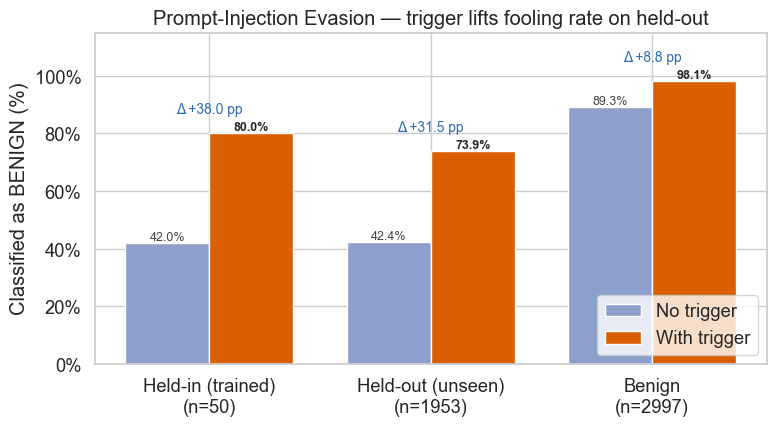

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(df_pinj))
w = 0.38

bars1 = ax.bar(x - w/2, df_pinj["baseline"]    * 100, w,
               label="No trigger",   color="#8da0cb", edgecolor="white")
bars2 = ax.bar(x + w/2, df_pinj["with_trigger"] * 100, w,
               label="With trigger", color="#d95f02", edgecolor="white")

for b, v in zip(bars1, df_pinj["baseline"]):
    ax.text(b.get_x()+b.get_width()/2, v*100+1, f"{v:.1%}",
            ha="center", fontsize=9, color="#444")
for b, v in zip(bars2, df_pinj["with_trigger"]):
    ax.text(b.get_x()+b.get_width()/2, v*100+1, f"{v:.1%}",
            ha="center", fontsize=9, fontweight="bold")

# Lift annotation between bars
for i, row in df_pinj.iterrows():
    y = max(row["baseline"], row["with_trigger"])*100 + 7
    ax.annotate(f"Δ {row['lift']*100:+.1f} pp", (i, y),
                ha="center", fontsize=10, color="#2b6cb0")

ax.set_xticks(x)
ax.set_xticklabels([f"{r['split']}\n(n={r['n']})" for _, r in df_pinj.iterrows()])
ax.set_ylabel("Classified as BENIGN (%)")
ax.set_ylim(0, 115)
ax.set_title("Prompt-Injection Evasion — trigger lifts fooling rate on held-out")
ax.legend(loc="lower right", frameon=True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}%"))
plt.tight_layout()
fig.savefig(f"{RESULTS_DIR}/fig_exp3pinj_grouped_bar.pdf", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## 3.2 Dumbbell — Lift per split, one view

Each row is a split. Open circle = baseline, filled circle = with trigger, and
the arrow between them makes the lift visible at a glance. Injection splits
(held-in, held-out) are colored identically to make generalization jump out
visually: the two arrows are nearly the same length.

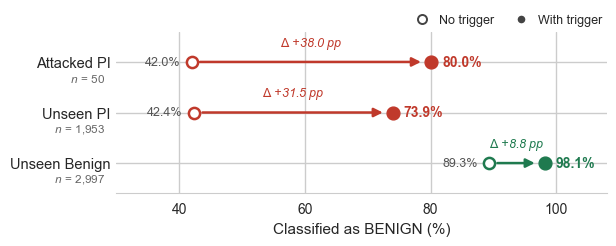

In [6]:
# ── Paper-ready dumbbell (§3.2) ──
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch

paper_rc = {
    "font.family": "Arial",
    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Arial:italic",
    "mathtext.bf": "Arial:bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

paper_labels = {"held_in": "Attacked PI", "held_out": "Unseen PI",
                "benign":  "Unseen Benign"}

with mpl.rc_context(paper_rc):
    fig, ax = plt.subplots(figsize=(6.4, 2.7))

    color_map = {"injection": "#C0392B", "benign": "#1F7A4F"}
    y_positions = np.arange(len(df_pinj))[::-1]

    for yp, (_, row) in zip(y_positions, df_pinj.iterrows()):
        c = color_map[row["kind"]]
        xb, xt = row["baseline"] * 100, row["with_trigger"] * 100
        ax.add_patch(FancyArrowPatch(
            (xb, yp), (xt, yp),
            arrowstyle="-|>", mutation_scale=13,
            color=c, lw=1.8, shrinkA=6, shrinkB=7, zorder=2,
        ))
        ax.scatter([xb], [yp], s=65, facecolors="white",
                   edgecolors=c, linewidths=1.8, zorder=3)
        ax.scatter([xt], [yp], s=85, color=c, zorder=4)
        ax.text(xb - 1.8, yp, f"{xb:.1f}%", ha="right", va="center",
                fontsize=9,  color="#555")
        ax.text(xt + 1.8, yp, f"{xt:.1f}%", ha="left",  va="center",
                fontsize=10, fontweight="bold", color=c)
        ax.text((xb + xt) / 2, yp + 0.22,
                f"$\Delta$ {row['lift']*100:+.1f} pp",
                ha="center", va="bottom", fontsize=9,
                color=c, style="italic")

    ax.set_yticks(y_positions)
    ax.set_yticklabels([paper_labels[r["split_key"]]
                        for _, r in df_pinj.iterrows()], fontsize=10.5)
    for yp, (_, row) in zip(y_positions, df_pinj.iterrows()):
        ax.annotate(
            r"$\mathit{n\,{=}\,}$" + f"{row['n']:,}",
            xy=(0, yp), xycoords=("axes fraction", "data"),
            xytext=(-8, -12), textcoords="offset points",
            ha="right", va="center", fontsize=8.5, color="#666",
        )

    ax.set_xlim(30, 108)
    ax.set_ylim(-0.6, len(df_pinj) - 0.4)

    ax.set_xlabel("Classified as BENIGN (%)")
    ax.set_xticks([40, 60, 80, 100])
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))

    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.yaxis.set_tick_params(length=0, pad=4)
    ax.xaxis.set_tick_params(length=3, width=0.8, color="#888")

    # Grid: very faint solid verticals at major xticks; 100% ceiling dashed.
    for xv in [40, 60, 80]:
        ax.axvline(xv, color="#EAEAEA", lw=0.7, zorder=0)
    ax.axvline(100, color="#B8B8B8", lw=0.7, ls=(0, (3, 3)), zorder=0)
    ax.set_axisbelow(True)

    legend_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="white",
               markeredgecolor="#444", markeredgewidth=1.4,
               markersize=6.5, label="No trigger"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#444",
               markersize=6.5, label="With trigger"),
    ]
    ax.legend(handles=legend_handles, loc="lower right",
              bbox_to_anchor=(1.0, 1.0), ncol=2,
              frameon=False, handletextpad=0.3,
              columnspacing=1.2, borderaxespad=0.0)

    plt.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/fig_exp3pinj_dumbbell.pdf",
                bbox_inches="tight", pad_inches=0.03)
    plt.show()


## 3.3 Stacked composition — What does the guard actually predict?

Horizontal stacked bars show the BENIGN / MALICIOUS composition of predictions
on each split, before and after the trigger. Makes the mass that "flipped"
from malicious→benign directly visible.

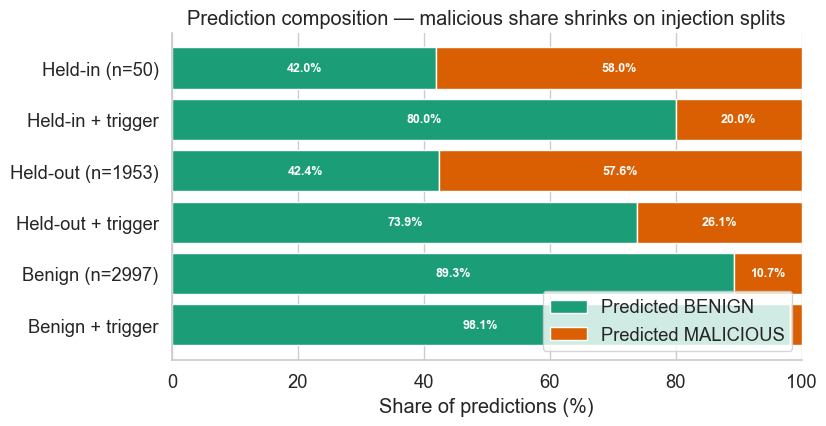

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))

order = [
    ("Held-in (n=50)",       "held_in",  False),
    ("Held-in + trigger",    "held_in",  True),
    ("Held-out (n=1953)",    "held_out", False),
    ("Held-out + trigger",   "held_out", True),
    ("Benign (n=2997)",      "benign",   False),
    ("Benign + trigger",     "benign",   True),
]
labels, benign_pct, mal_pct = [], [], []
for lab, key, triggered in order:
    d = pinj["eval"]["benign_with_trigger"] if (key == "benign" and triggered) else (
        pinj["eval"][key] if triggered else pinj["baseline"][key])
    n = d["n_total"]
    benign_pct.append(100 * d["n_predicted_benign"] / n)
    mal_pct.append(100 * d["n_predicted_malicious"] / n)
    labels.append(lab)

y = np.arange(len(labels))[::-1]
b1 = ax.barh(y, benign_pct, color="#1b9e77", edgecolor="white", label="Predicted BENIGN")
b2 = ax.barh(y, mal_pct, left=benign_pct, color="#d95f02",
             edgecolor="white", label="Predicted MALICIOUS")

for yy, bp, mp in zip(y, benign_pct, mal_pct):
    if bp > 7:
        ax.text(bp/2, yy, f"{bp:.1f}%", ha="center", va="center",
                color="white", fontsize=9, fontweight="bold")
    if mp > 7:
        ax.text(bp + mp/2, yy, f"{mp:.1f}%", ha="center", va="center",
                color="white", fontsize=9, fontweight="bold")

ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel("Share of predictions (%)")
ax.set_xlim(0, 100)
ax.set_title("Prediction composition — malicious share shrinks on injection splits")
ax.legend(loc="lower right", frameon=True)
for s in ("top","right"): ax.spines[s].set_visible(False)
plt.tight_layout()
fig.savefig(f"{RESULTS_DIR}/fig_exp3pinj_stacked.pdf", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## 3.4 Generalization gap — held-in vs held-out lift

The quantity of interest for a *universal* trigger is how much of the held-in
lift survives on held-out. A small gap = strong generalization.

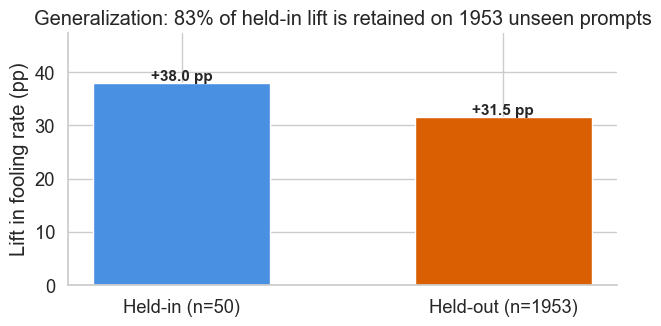

Held-in lift:  +38.0 pp
Held-out lift: +31.5 pp  (83% of held-in)
Generalization gap: 6.5 pp


In [8]:
lift_hi = df_pinj.loc[df_pinj["split_key"]=="held_in",  "lift"].iloc[0] * 100
lift_ho = df_pinj.loc[df_pinj["split_key"]=="held_out", "lift"].iloc[0] * 100
gap = lift_hi - lift_ho
retention = lift_ho / lift_hi

fig, ax = plt.subplots(figsize=(6.5, 3.5))
bars = ax.bar(["Held-in (n=50)", "Held-out (n=1953)"],
              [lift_hi, lift_ho],
              color=["#4a90e2", "#d95f02"], edgecolor="white", width=0.55)
for b, v in zip(bars, [lift_hi, lift_ho]):
    ax.text(b.get_x()+b.get_width()/2, v+0.6, f"+{v:.1f} pp",
            ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Lift in fooling rate (pp)")
ax.set_ylim(0, max(lift_hi, lift_ho) * 1.25)
ax.set_title(f"Generalization: {retention:.0%} of held-in lift is retained on {pinj['n_held_out']} unseen prompts")
for s in ("top","right"): ax.spines[s].set_visible(False)
plt.tight_layout()
fig.savefig(f"{RESULTS_DIR}/fig_exp3pinj_generalization.pdf", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

print(f"Held-in lift:  +{lift_hi:.1f} pp")
print(f"Held-out lift: +{lift_ho:.1f} pp  ({retention:.0%} of held-in)")
print(f"Generalization gap: {gap:.1f} pp")

## 3.5 ROC — threshold-free view of classifier degradation

Relying on a single decision threshold (argmax) hides the fact that a
defender could re-tune their threshold. The ROC curve answers: *across every
possible threshold*, how much separability does the classifier still have
between injections and benign prompts, under attack vs. not?

Requires scores from `scripts/opt-bench/exp3-pinj-scores.py` — run that once
to produce `exp3_pinj_scores_<model>.json`.

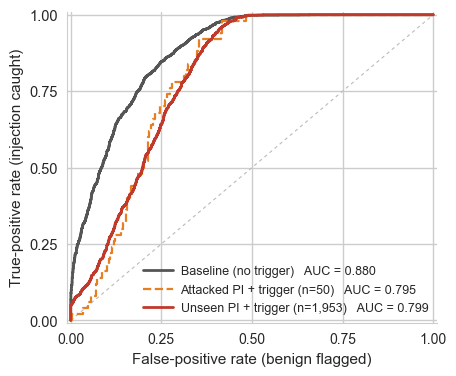


AUC summary
--------------------------------------------
  Baseline (no trigger)                  0.880
  Attacked PI + trigger (n=50)           0.795
  Unseen PI + trigger (n=1,953)          0.799


In [9]:
# ── Load classifier scores and plot ROC ──
from sklearn.metrics import roc_curve, auc

scores_files = sorted(glob.glob(f"{RESULTS_DIR}/exp3_pinj_scores_*.json"))
assert scores_files, (
    "No score file found. Run `python scripts/opt-bench/exp3-pinj-scores.py` first."
)
with open(scores_files[0], encoding="utf-8") as f:
    sc = json.load(f)

s = sc["scores"]

def roc(pos_scores, neg_scores):
    y = [1] * len(pos_scores) + [0] * len(neg_scores)
    p = list(pos_scores) + list(neg_scores)
    fpr, tpr, _ = roc_curve(y, p)
    return fpr, tpr, auc(fpr, tpr)

# All injections (clean) vs benign (clean) — baseline classifier
all_inj_clean = s["held_in_clean"] + s["held_out_clean"]

curves = [
    ("Baseline (no trigger)",
     roc(all_inj_clean,    s["benign_clean"]),
     "#555555", "-",  2.0),
    ("Attacked PI + trigger (n=50)",
     roc(s["held_in_trig"], s["benign_clean"]),
     "#E67E22", "--", 1.6),
    ("Unseen PI + trigger (n=1,953)",
     roc(s["held_out_trig"], s["benign_clean"]),
     "#C0392B", "-",  2.0),
]

with mpl.rc_context(paper_rc):
    fig, ax = plt.subplots(figsize=(4.8, 4.0))

    ax.plot([0, 1], [0, 1], color="#BBBBBB", lw=0.8, ls=(0, (3, 3)),
            zorder=1, label="_chance")

    for label, (fpr, tpr, auc_v), color, ls, lw in curves:
        ax.plot(fpr, tpr, color=color, lw=lw, ls=ls,
                label=f"{label}   AUC = {auc_v:.3f}", zorder=3)

    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)
    ax.set_xlabel("False-positive rate (benign flagged)")
    ax.set_ylabel("True-positive rate (injection caught)")
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))

    for s_name in ("top", "right"):
        ax.spines[s_name].set_visible(False)
    ax.tick_params(length=3, width=0.8, color="#888")
    for xv in [0.25, 0.5, 0.75]:
        ax.axvline(xv, color="#EEEEEE", lw=0.6, zorder=0)
        ax.axhline(xv, color="#EEEEEE", lw=0.6, zorder=0)
    ax.set_axisbelow(True)

    ax.legend(loc="lower right", frameon=False, handletextpad=0.6,
              handlelength=2.4, borderaxespad=0.3)

    plt.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/fig_exp3pinj_roc.pdf",
                bbox_inches="tight", pad_inches=0.03)
    plt.show()

# Print AUC table
print("\nAUC summary")
print("-" * 44)
for label, (_, _, auc_v), *_ in curves:
    print(f"  {label:38s} {auc_v:.3f}")


## 3.6 Paper recommendation — the figure we'd include

**Recommended plot: the dumbbell (§3.2).**

Why it wins over the alternatives:

- **One figure, one message.** The two injection arrows are visually the same
  length. The reader sees the generalization claim without reading any number.
- **Absolute rates are preserved.** Unlike a "lift-only" bar chart (§3.4),
  the reader still sees that baseline is ~42% and trigger pushes it to
  80% / 74% — matters because prompt-injection guards are usually quoted in
  fooling-rate, not lift.
- **Benign sits in the same frame.** The green arrow on a third row
  demonstrates no collateral damage (actually a tiny *improvement*, 89.3% →
  98.1%) without a separate chart — pre-empting the obvious reviewer question.
- **Compact.** It fits one column and leaves room for a caption.

The grouped-bar chart (§3.1) is the runner-up — it's more familiar to a broad
audience, but it spends horizontal space on two bars per split that a dumbbell
collapses to one arrow. Stacked bars (§3.3) show *composition* rather than
*change*, which is a different story than the one we want to tell.

### Suggested caption

> **A universal trigger optimized on 50 injection prompts generalizes to 1953
> unseen ones without harming benign classification.** Fraction of prompts
> classified as BENIGN by *Llama-Prompt-Guard-2-86M*, before (hollow) and
> after (filled) appending a 20-token trigger optimized via GCG+UAT on the
> 50 held-in injections. The held-in → held-out arrows have nearly identical
> lengths (+38.0 pp vs. +31.5 pp), indicating the trigger is genuinely
> universal rather than overfit. The benign split (n=2997) is largely
> unaffected (+8.8 pp), confirming low collateral damage.

### Numbers for the body text

- Trigger length: 20 tokens, optimized with 500 GCG+UAT steps on 50 prompts.
- Attack success (fooling rate): 42.4% → 73.9% on 1953 unseen injections.
- Benign accuracy: 89.3% → 98.1% (no degradation).

### Companion figure (appendix / supplementary)

The ROC plot in **§3.5** is the right partner figure if reviewers want a
*threshold-free* view: it shows that the degradation in separability
(AUC drop on the attacked curves) is not a threshold artefact — the
classifier's ranking ability itself collapses under the universal
trigger. The near-overlap of the two attacked curves (held-in vs
held-out) is the same generalization claim, told through AUC instead
of fooling rate.


---
# Section 4: Exp3 Prompt Recovery

Analyze the qualitative recovery produced by `exp3-promrec.py`: prompts sampled
from DiffusionDB are rendered with SD-2.1, inverted via MAC over OpenCLIP H/14,
then re-rendered from the recovered prompt.

**Main message to convey.** The recovered prompts look like gibberish, yet the
re-generated images preserve subject, style, and composition of the originals —
the "CLIP similarity is a faithful proxy for the generative distribution" story
from Williams et al. (2024).


In [ ]:
# -- Load exp3-promrec results --
from pathlib import Path
from PIL import Image

promrec_dir = Path(RESULTS_DIR) / "exp3_promrec"
with open(promrec_dir / "summary.json", encoding="utf-8") as f:
    promrec = json.load(f)

promrec_results = promrec["results"]
print(f"Loaded {len(promrec_results)} prompts from {promrec_dir}")
print(f"  SD:   {promrec['sd_model']}")
print(f"  CLIP: {promrec['clip_model']}")
print(f"  steps={promrec['num_steps']}  n_cand={promrec['n_candidates']}  seed={promrec['seed']}")
for r in promrec_results:
    print(f"\n[{r['prompt_idx']}] loss={r['best_loss']:.3f}")
    print(f"  orig: {r['original_prompt']}")
    print(f"  rec : {r['recovered_prompt']}")


## 4.1 Qualitative grid — original vs. recovered

Two-row grid (original on top, recovered on bottom). Paper-style: column per
prompt, prompt text shown above each image, no tick marks.


In [ ]:
import textwrap

def _wrap(s, width=34, max_lines=3):
    lines = textwrap.wrap(s, width=width)
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1][:width - 1] + "…"
    return "\n".join(lines)

n = len(promrec_results)
fig, axes = plt.subplots(
    2, n, figsize=(2.8 * n, 6.6), squeeze=False,
    gridspec_kw={"hspace": 0.55, "wspace": 0.08},
)

for col, r in enumerate(promrec_results):
    run_dir = promrec_dir / f"prompt_{r['prompt_idx']:02d}"
    axes[0, col].imshow(Image.open(run_dir / "original_image.png"))
    axes[1, col].imshow(Image.open(run_dir / "recovered_image.png"))
    for ax in axes[:, col]:
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_linewidth(0.4); sp.set_color("0.7")
    axes[0, col].set_title(_wrap(r["original_prompt"]),  fontsize=8, pad=4, color="#333333")
    axes[1, col].set_title(_wrap(r["recovered_prompt"]), fontsize=8, pad=4, color="#1f4e79")

axes[0, 0].set_ylabel("Original",  fontsize=12, fontweight="bold", labelpad=10)
axes[1, 0].set_ylabel("Recovered", fontsize=12, fontweight="bold", labelpad=10, color="#1f4e79")

fig.suptitle(
    f"Prompt Recovery — SD-2.1 + OpenCLIP H/14 + MAC "
    f"({promrec['num_steps']} steps, seed={promrec['seed']})",
    fontsize=12, y=0.995,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(f"{RESULTS_DIR}/fig_exp3promrec_grid.pdf", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


## 4.2 Recovery loss per prompt

Per-prompt best loss (≈ 1 − CLIP cos-sim between recovered-prompt embedding
and target-image embedding). Lower = tighter semantic match.


In [ ]:
idx_    = [r["prompt_idx"] for r in promrec_results]
losses_ = [r["best_loss"]  for r in promrec_results]

fig, ax = plt.subplots(figsize=(1.5 + 0.9 * n, 3.6))
bars = ax.bar(idx_, losses_, color="#1f4e79", width=0.6, edgecolor="white")
ax.set_xticks(idx_)
ax.set_xlabel("Prompt index")
ax.set_ylabel("Best loss (1 − cos-sim)")
ax.set_title("Recovery loss per prompt")
for b, v in zip(bars, losses_):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}",
            ha="center", va="bottom", fontsize=10)
ax.margins(y=0.15)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
plt.tight_layout()
fig.savefig(f"{RESULTS_DIR}/fig_exp3promrec_loss.pdf", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

print(f"Mean best loss: {sum(losses_) / len(losses_):.4f}")


## 4.3 Paper recommendation — the figure we'd include

**Recommended plot: the qualitative grid (§4.1).**

The story in prompt recovery is *semantic* rather than *lexical*: MAC finds
prompts with high CLIP similarity to the target image, and those prompts
re-generate images with matching subject/style/composition even when the
recovered text is gibberish. A grid shows this at a glance; a metric bar chart
does not.

### Suggested caption

> **MAC recovers semantically faithful prompts without lexical overlap.**
> Five prompts sampled from DiffusionDB are rendered with Stable Diffusion 2.1
> (top row, caption shown above each image). MAC is then run over the SD-2.1
> text encoder (OpenCLIP ViT-H/14) for 3000 steps with 8 free tokens,
> maximizing CLIP similarity between the text embedding and the original image.
> The recovered prompts (bottom row) re-generate images that preserve subject,
> style, and layout despite bearing little lexical resemblance to the
> originals.

### Numbers for the body text

- Optimizer: MAC (μ=0.6), 3000 steps, 512 candidates, 8 free tokens.
- Proxy: OpenCLIP ViT-H/14 (SD-2.1's native text encoder).
- Generation: SD-2.1 (`sd2-community/stable-diffusion-2-1`), 50 steps,
  768×768, seeded identically for original and recovered to isolate
  prompt-driven differences.
